In [1]:
import numpy as np
import ase
from ase import Atoms
from ase import io
from ase.io.espresso import write_espresso_in as write_in
from ase.io.espresso import read_espresso_out as read_out
from ase.io.lammpsdata import write_lammps_data
from ase.io.lammpsdata import read_lammps_data
from ase.io.lammpsrun import read_lammps_dump_text
from ase.io import write
from ase.io import read
from ase.calculators.espresso import Espresso
from ase.build import surface
from ase.build import sort
from ase.constraints import FixAtoms
import os
import sys
import matplotlib
matplotlib.use("agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pylab import *
from matplotlib import rc

In [2]:
# --- 1. User Inputs & Path Construction ---
scratch_base = f"./../.."

cif_rel_path = input(f"Enter the CIF path (e.g., systems/Si/Si.cif): ").strip()
cif_path = os.path.join(scratch_base, cif_rel_path)

# Verification Mode
mode = input("Enter verification type ('energycutoff' or 'kpoints'): ").strip().lower()

# Define directory based on mode
cif_dir = os.path.dirname(cif_path)
parent_output_dir = os.path.join(cif_dir, mode)

# Handle Logic for both modes
ecut_list = [100]  
kpts_list = [(4, 4, 4)] 

if mode == 'energycutoff':
    ecut_input = input("Enter the ecutwfc values separated by space (60 80 100): ")
    ecut_list = [int(x) for x in ecut_input.split()]
    fixed_k = input("Enter the fixed K-point mesh (e.g., 4 4 4): ")
    kpts_list = [tuple(map(int, fixed_k.split()))]

elif mode == 'kpoints':
    k_input = input("Enter the k-point mesh values (e.g., 4 6 8): ")
    kpts_list = [(int(x), int(x), int(x)) for x in k_input.split()]
    ecut_list = [int(input("Enter the fixed ecutwfc for these tests: "))]

else:
    print("Invalid mode. Choose 'energycutoff' or 'kpoints'.")
    sys.exit(1)

# --- 2. Fixed Parameters ---
#user_email = f"{roll_no}@smail.iitm.ac.in"
pseudo_dir = f"./../../pseudo/"
# Added Si, Mg, and O to the dictionary
pseudopotentials = {'Pt': 'Pt_ONCV_PBE-1.2.upf'}

try:
    atoms = io.read(cif_path, format='cif')
    ntyp = len(set(atoms.get_chemical_symbols()))
    nat = len(atoms)
except Exception as e:
    print(f"Error reading CIF file: {e}")
    sys.exit(1)

# --- 3. Automation Loop ---
print(f"\nCreating directories and files in: {parent_output_dir}")

for ecut in ecut_list:
    for kmesh in kpts_list:
        
        # Folder name is the variable being tested
        folder_name = str(ecut) if mode == 'energycutoff' else f"k_{kmesh[0]}"
        output_dir = os.path.join(parent_output_dir, folder_name)
        os.makedirs(output_dir, exist_ok=True)
        
        # --- Generate qe.sub ---
        sub_content = f"""#!/bin/bash
#SBATCH --job-name={mode}_{folder_name}
#SBATCH --nodes=2
#SBATCH --ntasks-per-node=24
#SBATCH --partition=standard
#SBATCH --time=01:00:00

mpirun -np 48 -mca coll_hcoll_enable 0 $HOME/qe-6.7/bin/pw.x -npool 1 -in pw.in > pw.out
"""
        with open(os.path.join(output_dir, "qe.sub"), "w") as f:
            f.write(sub_content)

        # --- Generate pw.in ---
        input_qe = {
            'control': {
                'calculation': 'scf',
                'outdir': './outdir',
                'pseudo_dir': pseudo_dir,
                'tprnfor': True,
                'disk_io': 'none',
                'restart_mode': 'from_scratch',
            },
            'system': {
                'ibrav': 0,
                'ntyp': ntyp,
                'nat': nat,
                'ecutwfc': ecut,
                'ecutrho': 4 * ecut,
                'input_dft': 'PBE',
                'nbnd': 44,
                'occupations': 'smearing', 
                'smearing': 'marzari-vanderbilt',
                'degauss': 0.02,
            },
            'electrons': {
                'mixing_beta': 0.1,
                'electron_maxstep': 200,
                'diagonalization': 'david',
                'conv_thr': 1e-06,
                'mixing_ndim': 8,
            },
        }

        write(os.path.join(output_dir, 'pw.in'), atoms, 
              format='espresso-in', 
              input_data=input_qe, 
              pseudopotentials=pseudopotentials, 
              kpts=kmesh, 
              koffset=(0, 0, 0))

        print(f" -> Created: {folder_name}")

# --- 4. Create the Master submit.sh script ---
submit_sh_path = os.path.join(parent_output_dir, "submit.sh")
submit_sh_content = """#!/bin/bash
# This script loops through subdirectories and submits jobs
for dir in */; do
    if [ -f "$dir/qe.sub" ]; then
        echo "Submitting job in $dir"
        cd "$dir"
        sbatch qe.sub
        cd ..
    fi
done
"""

with open(submit_sh_path, "w") as f:
    f.write(submit_sh_content)

# Make the submit.sh file executable
os.chmod(submit_sh_path, 0o755)

print(f"\nSuccess! Run 'bash {submit_sh_path}' to submit all jobs.")

Enter the CIF path (e.g., systems/Si/Si.cif):  ./energycutoffandkpointsoptimization/Pt.cif
Enter verification type ('energycutoff' or 'kpoints'):  energycutoff
Enter the ecutwfc values separated by space (60 80 100):  40 50 60 70 80 90 100
Enter the fixed K-point mesh (e.g., 4 4 4):  4 4 4



Creating directories and files in: ./../.././energycutoffandkpointsoptimization/energycutoff
 -> Created: 40
 -> Created: 50
 -> Created: 60
 -> Created: 70
 -> Created: 80
 -> Created: 90
 -> Created: 100

Success! Run 'bash ./../.././energycutoffandkpointsoptimization/energycutoff/submit.sh' to submit all jobs.


Enter CIF path (e.g., systems/Si/Si.cif):  ./energycutoffandkpointsoptimization/Pt.cif
Mode ('energycutoff' or 'kpoints'):  energycutoff



Value        | Total Energy (eV)    | Delta E (eV)   
-------------------------------------------------------
40.0         | -13203.656656        | ---            
50.0         | -13203.727775        | 0.071119       
60.0         | -13203.823773        | 0.095998       
70.0         | -13203.857446        | 0.033673       
80.0         | -13203.861716        | 0.004270       
90.0         | -13203.861838        | 0.000121       
100.0        | -13203.861915        | 0.000078       

Plot saved to: Convergence_energycutoff_Pt.png


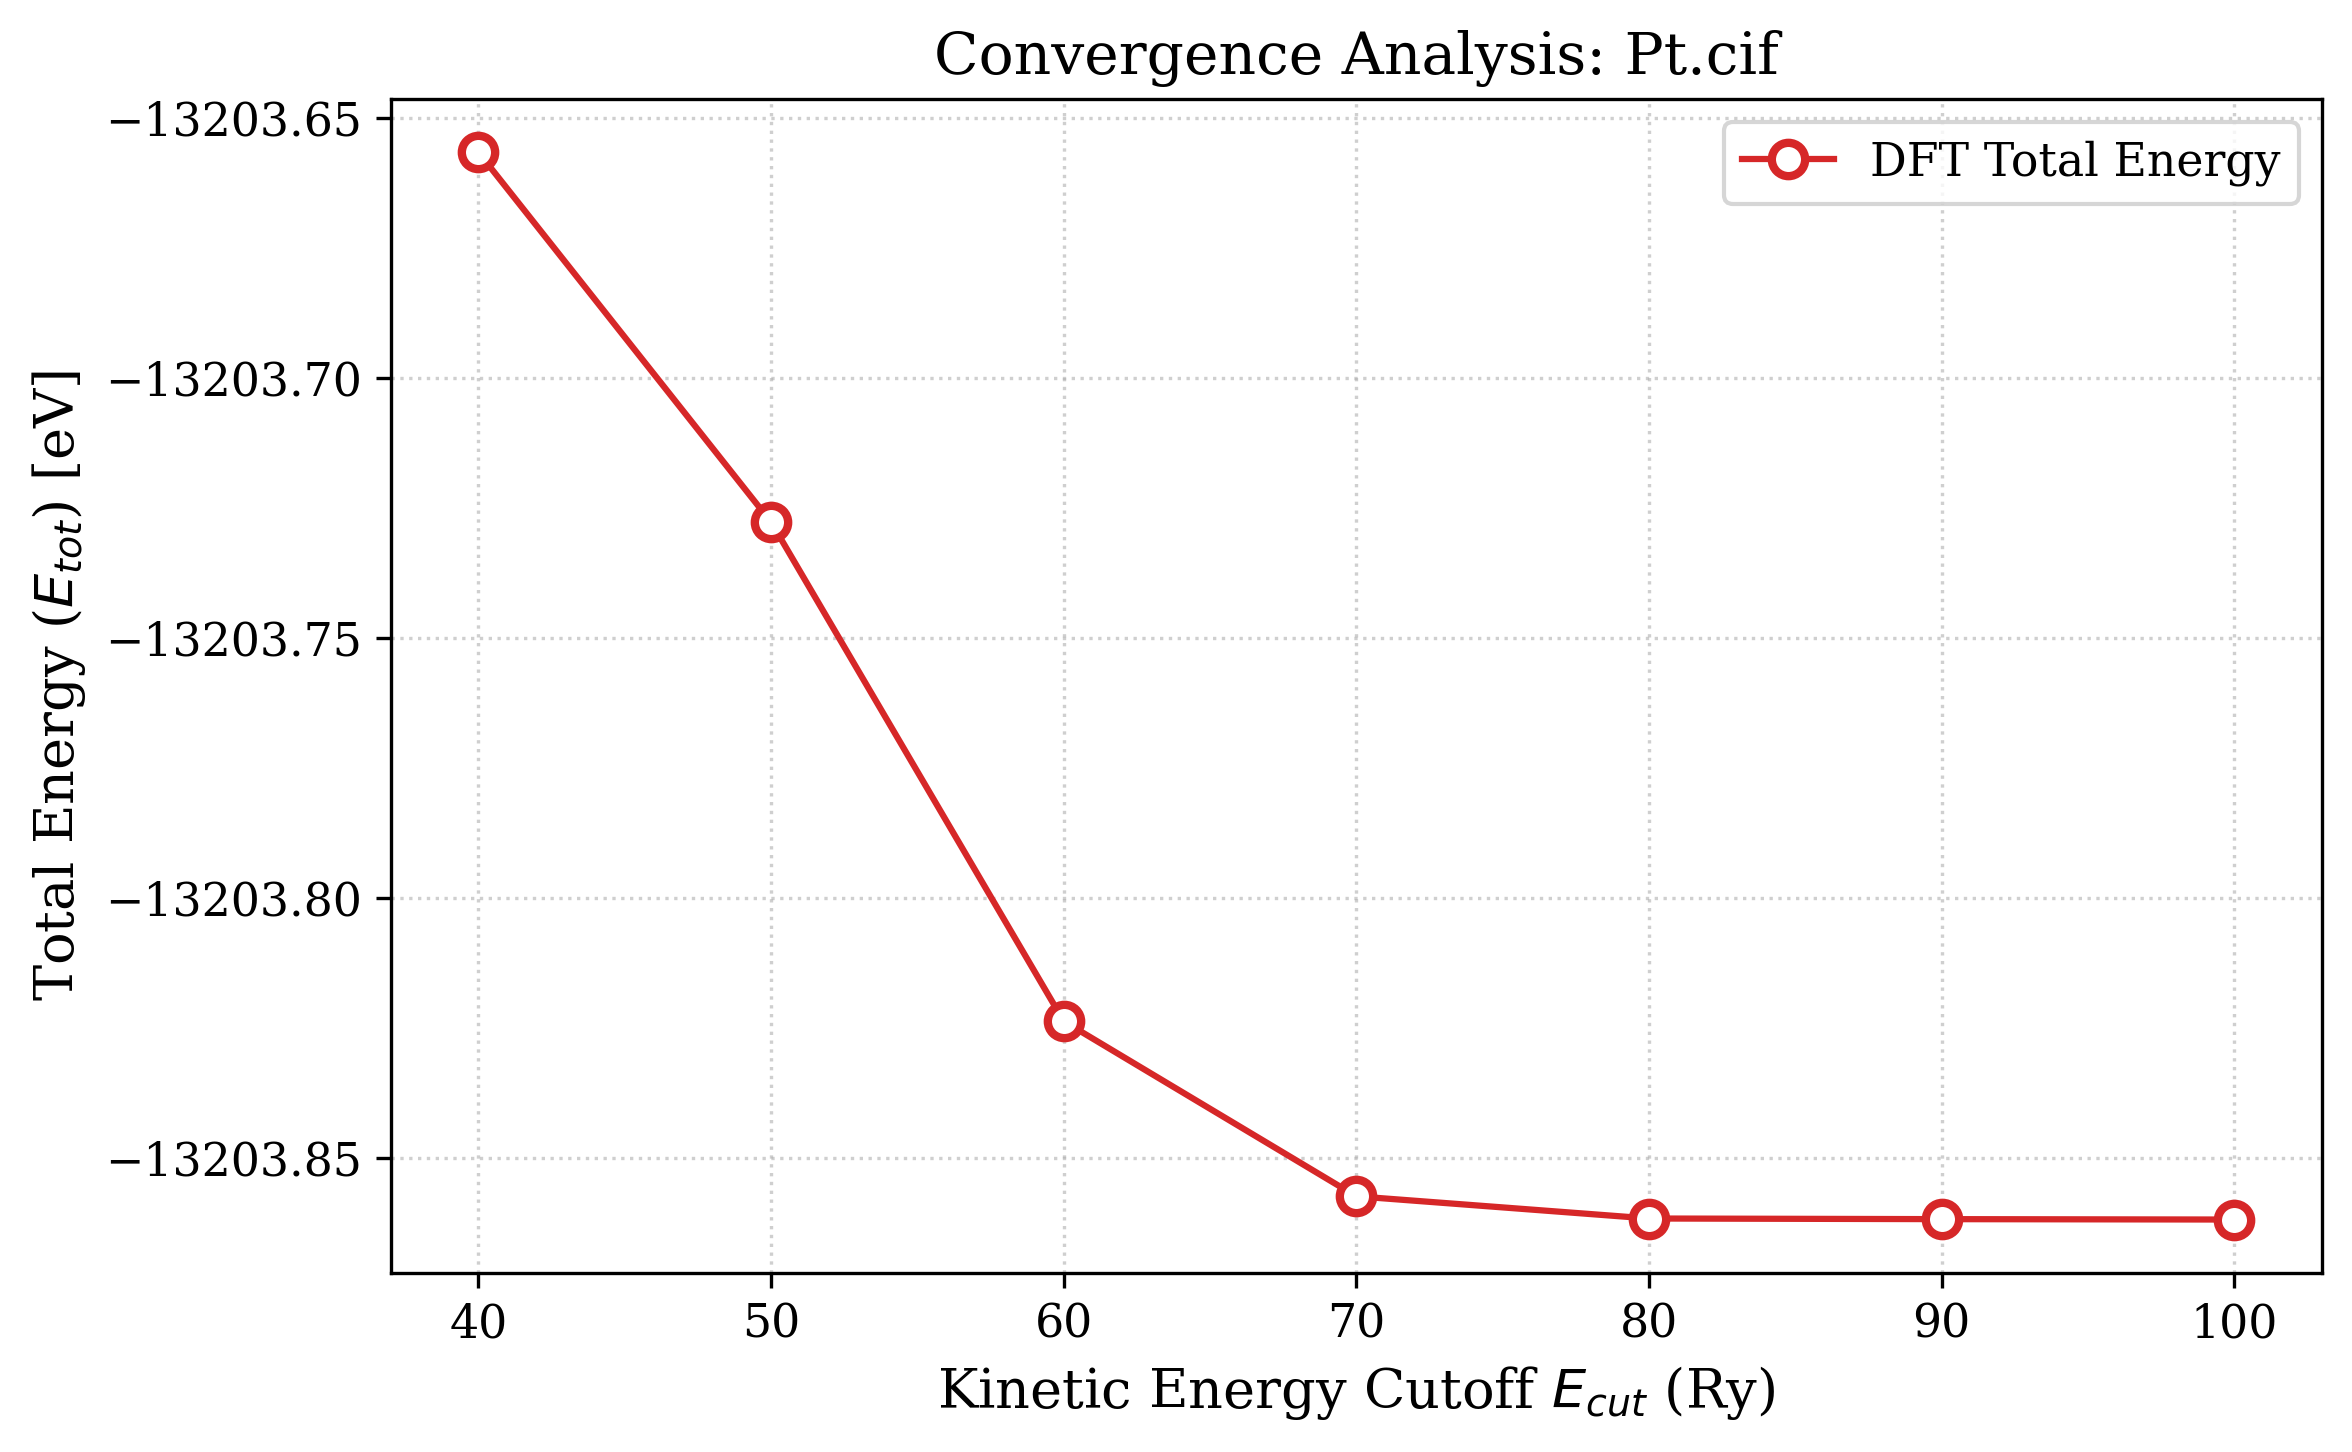

In [4]:
# --- 1. Style Configuration (Publication Standard) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 1.5,
    "figure.dpi": 300
})

# --- 2. Setup Paths ---
cif_rel_path = input("Enter CIF path (e.g., systems/Si/Si.cif): ").strip()
mode = input("Mode ('energycutoff' or 'kpoints'): ").strip().lower()

scratch_base = f"./../.."
cif_path = os.path.join(scratch_base, cif_rel_path)
data_dir = os.path.join(os.path.dirname(cif_path), mode)

x_values = []
potential_energy = []

# --- 3. Data Extraction ---
if not os.path.exists(data_dir):
    print(f"Error: Directory {data_dir} not found.")
    exit()

folders = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

print(f"\n{'Value':<12} | {'Total Energy (eV)':<20} | {'Delta E (eV)':<15}")
print("-" * 55)

for folder in folders:
    out_file = os.path.join(data_dir, folder, "pw.out")
    if os.path.exists(out_file):
        try:
            atoms = read(out_file, format='espresso-out')
            energy = atoms.get_potential_energy()
            val = float(folder.replace('k_', ''))
            x_values.append(val)
            potential_energy.append(energy)
        except:
            continue

if not x_values:
    print("No finished jobs found.")
    exit()

# Sort data for printing and plotting
sorted_data = sorted(zip(x_values, potential_energy))
x_plot, y_plot = zip(*sorted_data)

# Print values with Delta E calculation
for i in range(len(x_plot)):
    delta_str = "---"
    if i > 0:
        delta = abs(y_plot[i] - y_plot[i-1])
        delta_str = f"{delta:.6f}"
    print(f"{x_plot[i]:<12} | {y_plot[i]:<20.6f} | {delta_str:<15}")

# --- 4. High-Quality Plotting ---
%matplotlib inline
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x_plot, y_plot, marker='o', color='#d62728', markerfacecolor='white', 
        markeredgewidth=2, markersize=8, label='DFT Total Energy')

# REMOVE OFFSET (Shows full energy values on Y-axis)
ax.ticklabel_format(useOffset=False, style='plain', axis='y')

# Labels & Title
xlabel = "Kinetic Energy Cutoff $E_{cut}$ (Ry)" if mode == 'energycutoff' else "K-point Grid ($n \\times n \\times n$)"
ax.set_xlabel(xlabel)
ax.set_ylabel("Total Energy ($E_{tot}$) [eV]")
ax.set_title(f"Convergence Analysis: {os.path.basename(cif_rel_path)}")

# Add Grid
ax.grid(True, which='both', linestyle=':', alpha=0.6)

plt.legend(frameon=True, loc='best')
plt.tight_layout()

# Save image
output_fig = f"Convergence_{mode}_{os.path.basename(cif_rel_path).replace('.cif','')}.png"
plt.savefig(output_fig, bbox_inches='tight')
print(f"\nPlot saved to: {output_fig}")
plt.show()